# **STA 141A Report: Predicting Wildfire Incidence in the United States**
### Frank Y Mao 

### **Background**: In the midquarter report, we conducted preliminary exploratory data analysis and evaluated potential inference approaches for the highly skewed U.S. wildfire dataset using a 100k sample subset. In this expanded final report, we instead use the full historical wildfire dataset downloaded from Kaggle. This dataset compiles wildfire incident records from federal, state, and local fire management agencies across the United States. The dataset covers the period from 1992 to 2015 and contains approximately 1.88 million geo-referenced wildfire records (as opposed to the 188 million mentioned in the original project description). Wildfires are a major environmental and socio-economic hazard in the United States, affecting ecosystems, infrastructure, air quality, and public safety. Therefore, understanding the spatial and temporal patterns of wildfire occurrence is crucial for improving fire management strategies, risk assessment, and mitigation planning.

### **Abstract**: This project analyzes historical wildfire records across the United States from 1992–2015 using the 1.88 million wildfire dataset. After processing and aggregating the data into a county–month panel, EDA was conducted to examine spatial and temporal wildfire patterns. The analysis reveals clear geographic clustering of notable fires (≥100 acres). To predict the occurrence of notable wildfires, we implemented both a logistic regression benchmark model and a tree-based gradient boosting model (XGBoost). Model performance was evaluated using out-of-sample AUC across validation years. The results show that the XGBoost model substantially outperforms logistic regression, indicating that nonlinear relationships and interactions between predictors play an important role in wildfire occurrence. These findings underscore the potential of supervised machine learning approaches for wildfire prevention through risk prediction. 

## **Section I: Data Preprocessing**
### Packages used: 

In [12]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3
import plotly.express as px
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [ ]:
data_dir = Path(r"C:\Users\Frank\.cache\kagglehub\datasets\rtatman\188-million-us-wildfires\versions\2")
files = list(data_dir.glob("*"))
db_path = files[0] 
conn = sqlite3.connect(db_path)
query = """
SELECT
    FIRE_YEAR,
    DISCOVERY_DATE,
    CONT_DATE,
    FIRE_SIZE,
    STAT_CAUSE_DESCR,
    STATE,
    COUNTY,
    LATITUDE,
    LONGITUDE
FROM Fires
"""
df = pd.read_sql_query(query, conn)
df["STATE"] = df["STATE"].astype(str).str.strip()
df["COUNTY"] = df["COUNTY"].astype(str).str.strip()
df["DISCOVERY_DATE"] = pd.to_numeric(df["DISCOVERY_DATE"])
df["DISCOVERY_DATE"] = pd.to_datetime(
    df["DISCOVERY_DATE"],
    origin="julian",
    unit="D"
)
df["CONT_DATE"] = pd.to_numeric(df["CONT_DATE"])
df["CONT_DATE"] = pd.to_datetime(
    df["CONT_DATE"],
    origin="julian",
    unit="D"
)
df["year"] = df["DISCOVERY_DATE"].dt.year
df["month"] = df["DISCOVERY_DATE"].dt.month
df["year_month"] = df["DISCOVERY_DATE"].dt.to_period("M")
#df was saved as fire.pkl"

### The full 1.88 million wildfire records were first downloaded from Kaggle. Utilizing the SQLite database engine, we selected only the columns anticipated to be necessary for downstream analysis and inference. These included the year of the fire, discovery date, containment date, fire size, cause description, state, county, and geographic coordinates (latitude and longitude). The first preprocessing step was to convert the default Julian date format used in the database into a more recognizable YYYY-MM-DD date format. This dataset was then saved as fire.pkl, as noted in the code comments.</p>


In [ ]:
df["notable_fire"] = (df["FIRE_SIZE"] >= 100).astype(int)
county_month = (
    df.groupby(["STATE", "COUNTY", "year", "month"], dropna=False)
      .agg(
          fire_count=("FIRE_SIZE", "size"),
          notable_fire_count=("notable_fire", "sum"),
          total_acres=("FIRE_SIZE", "sum"),
          max_fire_size=("FIRE_SIZE", "max"),
          mean_fire_size=("FIRE_SIZE", "mean"),
          median_fire_size=("FIRE_SIZE", "median"),
      )
      .reset_index()
)
county_month["target"] = (county_month["notable_fire_count"] > 0).astype(int) #why? 
county_month["STATE"] = county_month["STATE"].astype(str).str.strip()
county_month["COUNTY"] = county_month["COUNTY"].astype(str).str.strip().str.zfill(3)
county_month["year"] = county_month["year"].astype(int)
county_month["month"] = county_month["month"].astype(int)
all_counties = (
    county_month[["STATE", "COUNTY"]]
    .drop_duplicates()
    .sort_values(["STATE", "COUNTY"])
    .reset_index(drop=True)
)
all_months = pd.date_range("1992-01-01", "2015-12-01", freq="MS")
month_df = pd.DataFrame({
    "date": all_months,
    "year": all_months.year,
    "month": all_months.month
})
all_counties["key"] = 1
month_df["key"] = 1
full_panel = (
    all_counties.merge(month_df, on="key")
    .drop(columns="key")
    .sort_values(["STATE", "COUNTY", "year", "month"])
    .reset_index(drop=True)
)
model_df = full_panel.merge(
    county_month,
    on=["STATE", "COUNTY", "year", "month"],
    how="left"
)
zero_fill_cols = [
    "fire_count",
    "notable_fire_count",
    "total_acres",
    "max_fire_size",
    "mean_fire_size",
    "median_fire_size",
]
for col in zero_fill_cols:
    model_df[col] = model_df[col].fillna(0)
model_df["target"] = (model_df["notable_fire_count"] > 0).astype(int)
# county_month was saved as "county.pkl"
# model_df is model.pkl

### The spatial resolution for the analysis was defined at the county level, rather than using a coordinate grid. The truncated wildfire dataset was therefore aggregated into a county–month dataset. Based on the midquarter report, we selected **100 acres** as the cutoff for defining a notable wildfire and labeled as binary outcome variable. The previously suggested 300-acre cutoff corresponded to the Class E classification, but we instead moved down one category to include Class D fires and above, according to the National Wildfire Coordinating Group. </p> We believe this classification remains meaningful while increasing the number of notable fire events, thereby improving exposure to notable fire occurrences and strengthening the applicability of predictive inference. Similarly, we constructed the complete county–month grid using unique state–county combinations, since some numerical county identifiers may be duplicated across different states. The wildfire records were then merged with this grid to produce the final dataset used for analysis (saved as model.pkl).</p> However, it is worth noting that if a state–county combination never experienced a wildfire during the recorded period from 1992 to 2015, it would not appear in the dataset and is therefore excluded from the analysis.<p>

In [4]:
model_df = pd.read_pickle("model.pkl")
model_df.head()

,STATE,COUNTY,date,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,median_fire_size,target
0,AK,020,1992-01-01,1992,1,0.0,0.0,0.0,0.0,0.0,0.0,0
1,AK,020,1992-02-01,1992,2,0.0,0.0,0.0,0.0,0.0,0.0,0
2,AK,020,1992-03-01,1992,3,0.0,0.0,0.0,0.0,0.0,0.0,0
3,AK,020,1992-04-01,1992,4,0.0,0.0,0.0,0.0,0.0,0.0,0
4,AK,020,1992-05-01,1992,5,0.0,0.0,0.0,0.0,0.0,0.0,0


In [5]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544256 entries, 0 to 1544255
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   STATE               1544256 non-null  object        
 1   COUNTY              1544256 non-null  object        
 2   date                1544256 non-null  datetime64[ns]
 3   year                1544256 non-null  int32         
 4   month               1544256 non-null  int32         
 5   fire_count          1544256 non-null  float64       
 6   notable_fire_count  1544256 non-null  float64       
 7   total_acres         1544256 non-null  float64       
 8   max_fire_size       1544256 non-null  float64       
 9   mean_fire_size      1544256 non-null  float64       
 10  median_fire_size    1544256 non-null  float64       
 11  target              1544256 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int32(2), int64(1), object(2)
memory

In [6]:
model_df.describe(include="all")

,STATE,COUNTY,date,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,median_fire_size,target
count,1544256,1544256,1544256,1.544256e+06,1.544256e+06,1.544256e+06,1.544256e+06,1.544256e+06,1.544256e+06,1.544256e+06,1.544256e+06,1.544256e+06
unique,52,3161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,TX,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,80640,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2003-12-16 10:59:59.999999104,2.003500e+03,6.500000e+00,1.217716e+00,3.502852e-02,9.074438e+01,5.275420e+01,1.150279e+01,7.585863e+00,1.611197e-02
min,NaN,NaN,1992-01-01 00:00:00,1.992000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,1997-12-24 06:00:00,1.997750e+03,3.750000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,NaN,NaN,2003-12-16 12:00:00,2.003500e+03,6.500000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,NaN,NaN,2009-12-08 18:00:00,2.009250e+03,9.250000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,NaN,NaN,2015-12-01 00:00:00,2.015000e+03,1.200000e+01,2.304000e+03,1.850000e+02,4.779145e+06,6.069450e+05,4.276960e+05,4.276960e+05,1.000000e+00


### Lastly, we filled in the county–month dataset by replacing NA values with 0. In this case, due to the selection of a limited set of predictors and the aggregation at the county level, no substantial missing data were encountered. This dataset represents the initial dataset intended for predictive modeling, and summary statistics are shown above. Additional variables and transformations are introduced later in the EDA section.<p>

## **Section II: ED Exploratory Data Analysis**
## Spatial Pattern

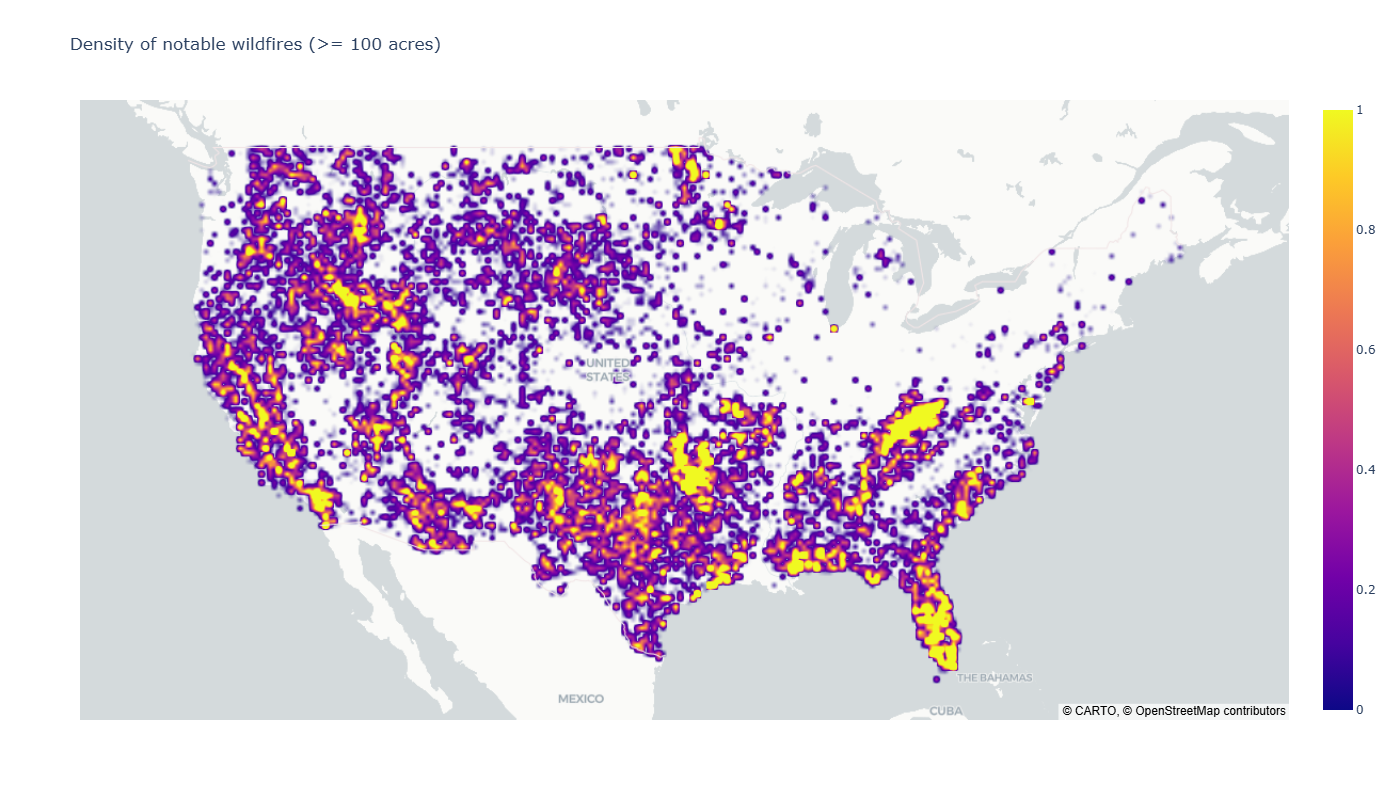

In [29]:
df = pd.read_pickle("fire.pkl")
notable = df[df["FIRE_SIZE"] >= 100].copy()
fig = px.density_map(
    notable,
    lat="LATITUDE",
    lon="LONGITUDE",
    z=None,
    radius=2,
    center=dict(lat=38, lon=-96),
    zoom=3.6,
    map_style="carto-positron",
    title="Density of notable wildfires (>= 100 acres)"
)
fig.update_layout(width=1200, height=800)
fig.show()

### Our EDA intuition first focused on examining the spatial patterns of wildfire occurrence. Using the original 1.8 million wildfire records, we plotted a density map of all notable fire events (defined as fires ≥ 100 acres in size). From the density map, an initial observation is that a large number of notable fires appear to be concentrated in southern states such as Texas and Kentuchy. Other states, including Florida, California, and Idaho, also appear to show relatively high-density regions highlighted in yellow. While these observations are not conclusive, they motivated the initial idea of applying clustering to identify potential spatial groupings of wildfire activity, as suggested by Dr. Chan. <p>

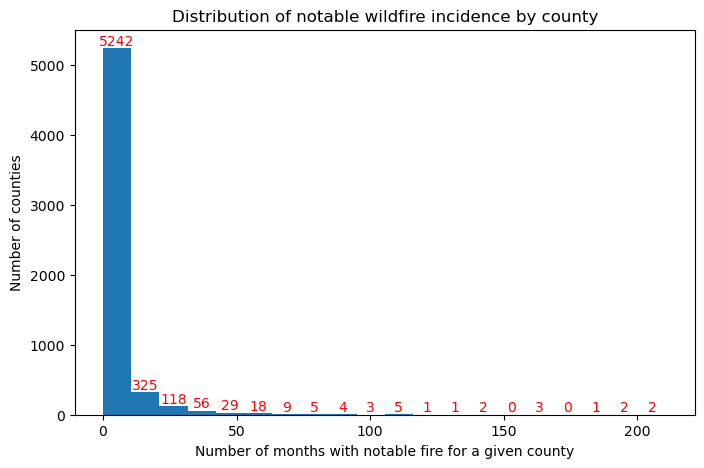

In [20]:
county_month=pd.read_pickle("county.pkl")
county_month["target"] = (county_month["notable_fire_count"] > 0).astype(int)
county_summary = (
    county_month.groupby(["STATE", "COUNTY"])
    .agg(
        total_months=("target", "size"),
        positive_months=("target", "sum"),
        total_fires=("fire_count", "sum"),
        total_notable=("notable_fire_count", "sum")
    )
    .reset_index()
)
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(county_summary["positive_months"], bins=20)
for count, patch in zip(counts, patches):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    plt.text(x, y, int(count), ha="center", va="bottom",color="red")
plt.xlabel("Number of months with notable fire for a given county")
plt.ylabel("Number of counties")
plt.title("Distribution of notable wildfire incidence by county")
plt.show()

### To further illustrate this pattern, we plotted a histogram showing the distribution of counties based on the total number of notable fires recorded between 1992 and 2015. As expected, the number of counties with fewer than 10 notable fires far exceeded the rest. This observation is consistent with the insight obtained from the mid-quarter report. Therefore, to better represent temporal trends, we increased the spatial resolution of the analysis through clustering. <p>

## Clustering for better Spatial Resolution in Temporal Pattern

In [ ]:
baseline = model_df[(model_df["year"] >= 1992) & (model_df["year"] <= 2000)].copy()
county_cluster_df = (
    baseline.groupby(["STATE", "COUNTY"], as_index=False)
    .agg(
        mean_fire_count=("fire_count", "mean"),
        mean_notable_fire_count=("notable_fire_count", "mean"),
        mean_total_acres=("total_acres", "mean"),
        positive_month_rate=("fire_count", lambda s: (s > 0).mean()),
        notable_month_rate=("target", "mean"),
        mean_max_fire_size=("max_fire_size", "mean")
    )
)
cluster_features = [
    "mean_fire_count", # average number of recorded fires per county-month during baseline
    "mean_notable_fire_count",  # average number of notable fires (>= 300 acres) per county-month during the baseline 
    "mean_total_acres", # average total acres burned per county-month during the baseline
    "positive_month_rate", # proportion of months in the baseline period with at least one recorded fire
    "notable_month_rate", # proportion of months in the baseline period with at least one notable fire.
    "mean_max_fire_size" # average of the monthly maximum fire size within each county
]
X = county_cluster_df[cluster_features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
county_cluster_df["cluster"] = kmeans.fit_predict(X_scaled)
model_df_cluster = model_df.merge(
    county_cluster_df[["STATE", "COUNTY", "cluster"]],
    on=["STATE", "COUNTY"],
    how="left"
)
# model_df_cluster is stored as model_cluster.pkl

### We applied unsupervised K-means clustering with 6 cluster centers and 20 iterations. The clustering features were calculated based on the number of notable fires and the individual recorded fire sizes from the original dataset (with some temporla information like the positive month rate). Instead of using the entire dataset, we restricted the clustering step to the **1992–2000** period in order to evaluate whether state–county cluster assignments would need to change over time (i.e., for potential rolling clustering). <p>

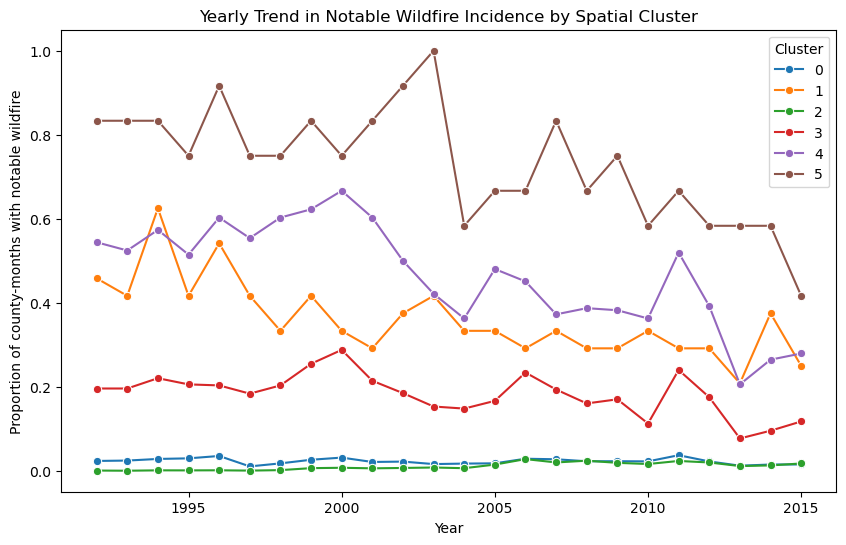

In [32]:
model_df_cluster = pd.read_pickle("model_cluster.pkl")
plt.figure(figsize=(10,6))
cluster_year = (
    model_df_cluster.groupby(["cluster", "year"], as_index=False)["target"]
    .mean()
)
sns.lineplot(
    data=cluster_year,
    x="year",
    y="target",
    hue="cluster",
    palette="tab10",
    marker="o"
)
plt.title("Yearly Trend in Notable Wildfire Incidence by Spatial Cluster")
plt.xlabel("Year")
plt.ylabel("Proportion of county-months with notable wildfire")
plt.legend(title="Cluster")
plt.show()

### Next, we plotted the yearly trend for each cluster center based on the proportion of state–county units experiencing a notable fire in that year. The trends for the clusters remain largely separated, with only minor overlap between clusters 4 and 1 around 2013. 
### For the low fire-incidence clusters (0 and 2), the proportion of counties with notable fires remains essentially flat and close to zero throughout the study period. In contrast, the remaining clusters with higher fire occurrence show a noticeable spike around 2000–2002, followed by a gradual decline, and another increase around 2011. A linear regression trend suggests that the proportion of counties experiencing notable fires has gradually decreased over time for clusters 1, 4, and 5. <p>

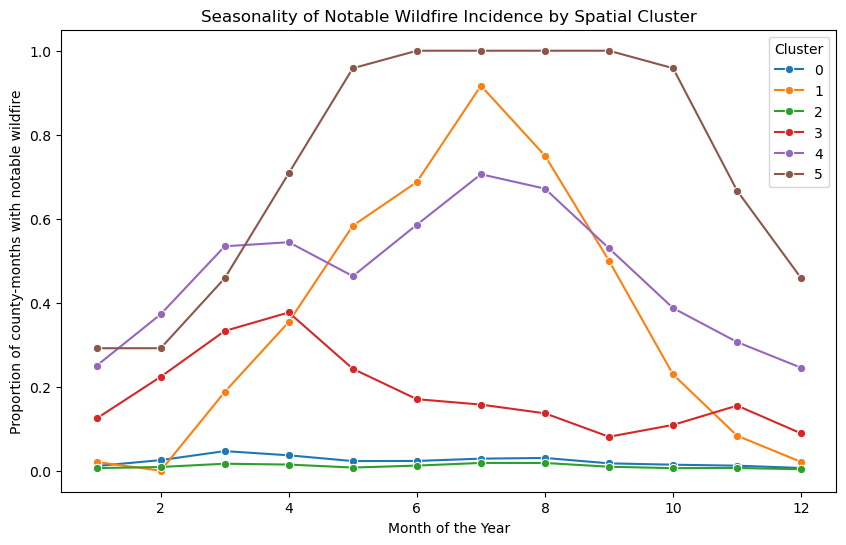

In [24]:
plt.figure(figsize=(10,6))
cluster_month = (
    model_df_cluster.groupby(["cluster", "month"], as_index=False)["target"]
    .mean()
)
sns.lineplot(
    data=cluster_month,
    x="month",
    y="target",
    hue="cluster",
    palette="tab10",
    marker="o"
)
plt.title("Seasonality of Notable Wildfire Incidence by Spatial Cluster")
plt.xlabel("Month of the Year")
plt.ylabel("Proportion of county-months with notable wildfire")
plt.legend(title="Cluster")
plt.show()

### Next, we examined the seasonality of the cluster centers by collapsing the data across years. As expected, clusters 0 and 2 remain relatively flat throughout the year. Notably, clusters 1, 4, and 5 show a pronounced increase from May to September, which aligns with the intuition that summer months in many state–county regions present higher wildfire risk. Interestingly, cluster 3 exhibits a different seasonal pattern, with a peak around April that gradually tapers off during the summer months. <p>

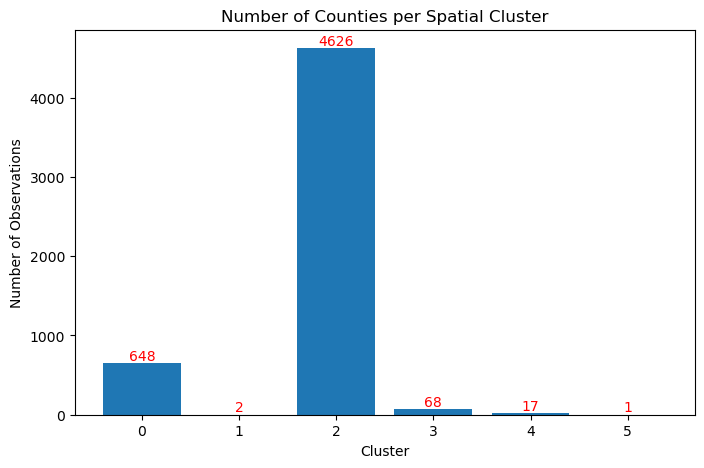

In [33]:
plt.figure(figsize=(8, 5))
df = pd.read_pickle("fire.pkl")
county_coords = (
    df.groupby(["STATE", "COUNTY"], as_index=False)
      .agg(
          LATITUDE=("LATITUDE", "mean"),
          LONGITUDE=("LONGITUDE", "mean")
      )
)
county_cluster_map = (
    model_df_cluster[["STATE", "COUNTY", "cluster"]]
    .drop_duplicates()
    .merge(county_coords, on=["STATE", "COUNTY"], how="left")
)
cluster_counts = county_cluster_map["cluster"].value_counts().sort_index()
bars = plt.bar(cluster_counts.index, cluster_counts.values)
for bar in bars:
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    plt.text(x, y, int(y), ha="center", va="bottom", color="red")
plt.xlabel("Cluster")
plt.ylabel("Number of Observations")
plt.title("Number of Counties per Spatial Cluster")
plt.show()

### We next quantified the number of counties assigned to each cluster. As expected, clusters 0 and 2 contain the majority of counties, accounting for a combined total of 5,274 counties. Cluster 3 ranks third, containing 68 counties, while clusters 1, 4, and 5 together account for only 20 counties in total.
### This observation informs some considerations for downstream model training. With cluster labels added to the dataset (saved as model_cluster.pkl), it may not be necessary to preserve all six cluster labels, as doing so could distribute predictive weight across very small groups. Instead, the clusters could be consolidated into broader categories, such as low fire risk (clusters 0 and 2) and elevated fire risk (clusters 1, 3, 4, and 5).

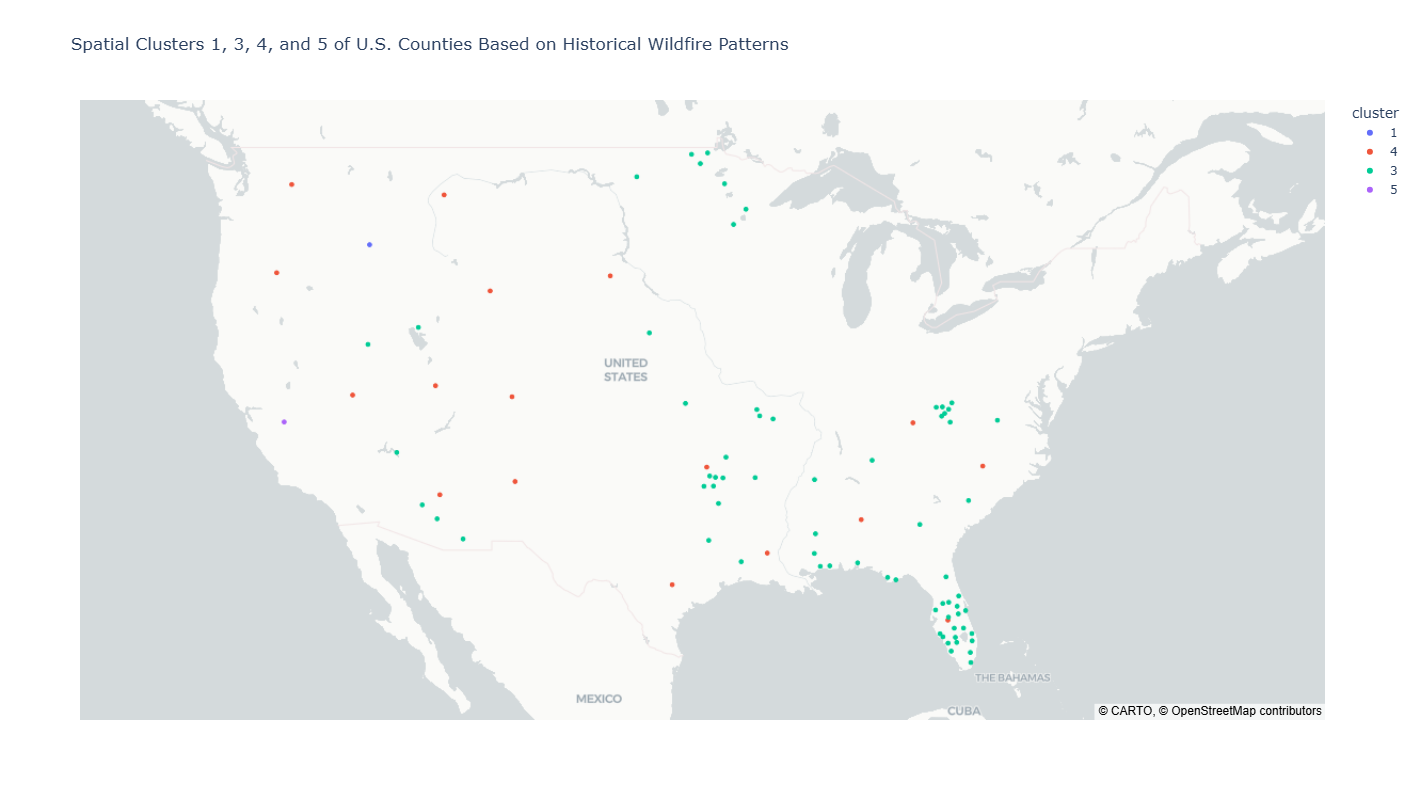

In [46]:
county_cluster_map["cluster"] = county_cluster_map["cluster"].astype(str)
fig = px.scatter_map(
    county_cluster_map,
    lat="LATITUDE",
    lon="LONGITUDE",
    color="cluster",
    hover_data=["STATE", "COUNTY"],
    center=dict(lat=38, lon=-96),
    zoom=3.6,
    map_style="carto-positron",
    title="Spatial Clusters of U.S. Counties Based on Historical Wildfire Patterns"
)
fig.update_layout(width=1200, height=800)

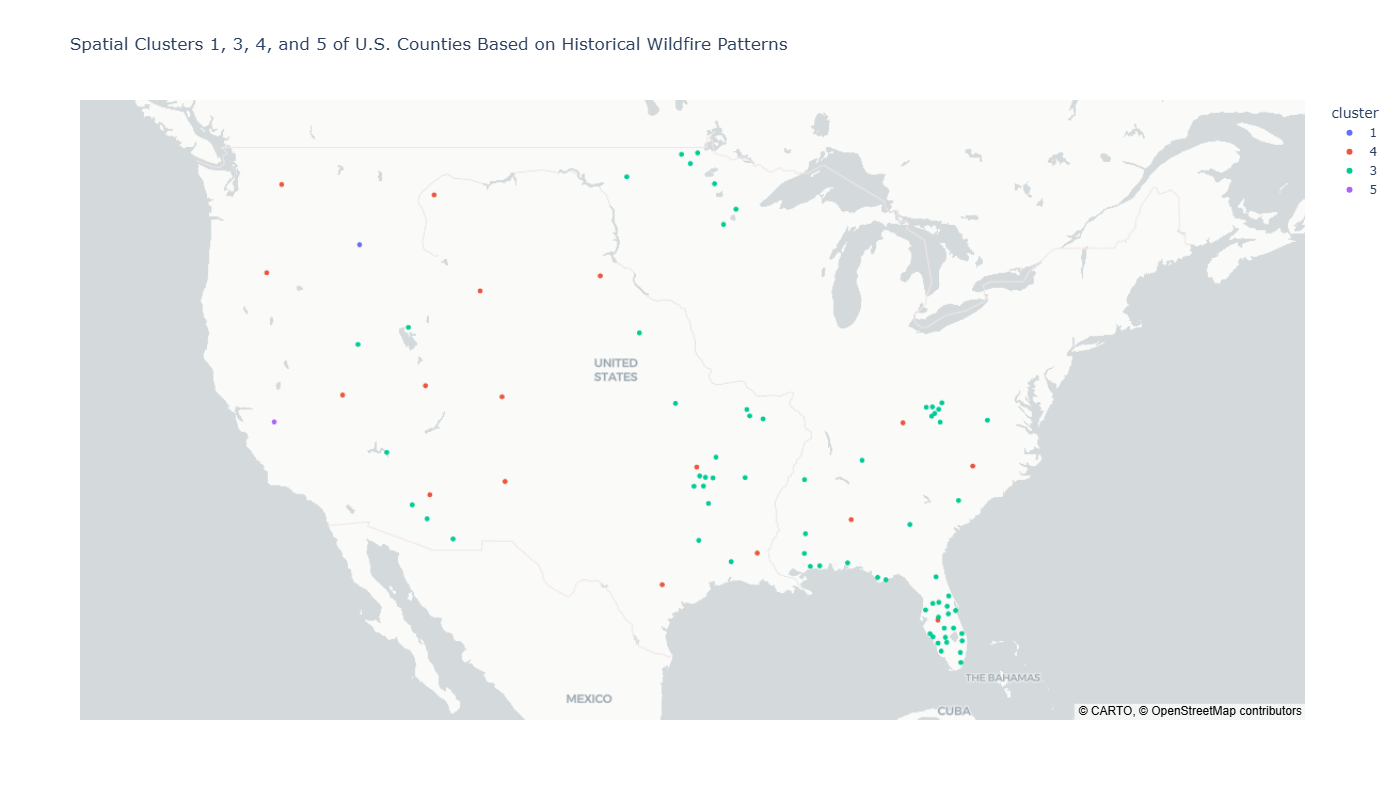

In [47]:
filtered_df = county_cluster_map[~county_cluster_map["cluster"].isin(["0", "2"])]
fig = px.scatter_map(
    filtered_df,
    lat="LATITUDE",
    lon="LONGITUDE",
    color="cluster",
    hover_data=["STATE", "COUNTY"],
    center=dict(lat=38, lon=-96),
    zoom=3.6,
    map_style="carto-positron",
    title="Spatial Clusters 1, 3, 4, and 5 of U.S. Counties Based on Historical Wildfire Patterns"
)
fig.update_layout(width=1200, height=800)

### Lastly, we visualized the spatial distribution of the cluster centers (top panel) and highlighted clusters 1, 3, 4, and 5 specifically. We observe that the single county belonging to cluster 5 is located in California, representing the highest fire risk based on both seasonality and yearly trend analyses, as it clearly stands out from all other counties. Upon closer inspection, this county corresponds to Madera County, located north of Fresno.
### For cluster 3, the counties are geographically scattered; however, a larger proportion are located in Florida and other southern states. This spatial pattern may partially explain the earlier seasonal peak observed for this cluster, as these regions may experience higher temperatures or heat waves earlier in the year, and in some areas may contain dense forested land with relatively lower population density (except Florida).The single county in cluster 1 was identified as Cascade County in Idaho. Note that this analysis focuses on the mainland United States, excluding Alaska and associated islands.

## **Section III: Modling**
## Baseline Model

In [11]:
df = pd.read_csv("../Data/wildfires_sample_100k.csv", low_memory=False)
wildfires = (
    df[["FIRE_YEAR", "DISCOVERY_DOY", "FIRE_SIZE", "LATITUDE", "LONGITUDE", "STATE"]]
    .copy()
)
wildfires["STATE"] = wildfires["STATE"].astype("category")
fires = wildfires.copy()
fires["FIRE_DATE"] = pd.to_datetime(
    fires["FIRE_YEAR"].astype(str) + "-" + fires["DISCOVERY_DOY"].astype(str),
    format="%Y-%j"
)
fires["YEAR"] = fires["FIRE_DATE"].dt.year
fires["MONTH"] = fires["FIRE_DATE"].dt.month
notable_threshold_acres = 100
notable_fires = fires[fires["FIRE_SIZE"] >= notable_threshold_acres]
print("Number of notable fires:", notable_fires.shape[0])

Number of notable fires: 2907


### As advised by Dr. Chan, we constructed a baseline benchmark model using the 100k wildfire data sample. We also adjusted the notable fire threshold from the original 300 acres to 100 acres in order to maintain consistency with the dataset definition used in this analysis. <p>

In [ ]:
notable_fires = notable_fires.copy()
notable_fires["lat_bin"] = np.floor(notable_fires["LATITUDE"]).astype(int)
notable_fires["lon_bin"] = np.floor(notable_fires["LONGITUDE"]).astype(int)
notable_fires["ym"] = notable_fires["YEAR"] * 100 + notable_fires["MONTH"]
grid_month_fire = (
    notable_fires
    .groupby(["lat_bin", "lon_bin", "ym"], as_index=False)
    .size()
    .rename(columns={"size": "n_fires"})
)
grid_month_fire["fire_this_month"] = 1
grid_month_fire.head()
# ---- Build panel (all grid cells that appear at least once) ----
all_grids = grid_month_fire[["lat_bin", "lon_bin"]].drop_duplicates().copy()
min_ym = grid_month_fire["ym"].min()
max_ym = grid_month_fire["ym"].max()
start_date = pd.Timestamp(year=min_ym // 100, month=min_ym % 100, day=1)  
end_date   = pd.Timestamp(year=max_ym // 100, month=max_ym % 100, day=1)
all_months = pd.DataFrame({
    "date": pd.date_range(start=start_date, end=end_date, freq="MS")
})
all_months["year"] = all_months["date"].dt.year
all_months["month"] = all_months["date"].dt.month
all_months["ym"] = all_months["year"] * 100 + all_months["month"]
all_months = all_months[["ym", "year", "month"]]
panel_1= (
    all_grids.merge(all_months, how="cross")
    .merge(
        grid_month_fire[["lat_bin", "lon_bin", "ym", "fire_this_month"]],
        on=["lat_bin", "lon_bin", "ym"],
        how="left"
    )
)
panel_1["fire_this_month"] = panel_1["fire_this_month"].fillna(0).astype(int)

### We then constructed the dataset panel used for the baseline model. Specifically, we generated a full coordinate grid (1° × 1°) by month panel and merged it with the 100k wildfire dataset. <p>

In [ ]:
panel_ref=panel_1.copy()
panel_2 = panel_1.sort_values(["lat_bin", "lon_bin", "ym"])
panel_2["y_next"] = (
    panel_ref.groupby(["lat_bin", "lon_bin"])["fire_this_month"]
    .shift(-1)
)
panel_2= panel_2.dropna(subset=["y_next"])
panel_2["y_next"] = panel_2["y_next"].astype(int)
print(panel_2["y_next"].value_counts())
panel=panel_2.copy()
def mode_state(x):
    return x.value_counts().idxmax()
grid_state = (
    notable_fires
    .groupby(["lat_bin", "lon_bin"])["STATE"]
    .apply(mode_state)
    .reset_index()
    .rename(columns={"STATE": "state"})
)
panel = panel.merge(
    grid_state,
    on=["lat_bin", "lon_bin"],
    how="left"
)
panel["month_sin"] = np.sin(2 * np.pi * panel["month"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month"] / 12)

### We resolved the coordinate grid–state assignment issue by attributing each grid cell to the state with the highest occurrence within that grid. The corresponding seasonality variables were then assigned to the full data panel using sin and cos functions. <p>

In [ ]:
grid_fire_size = (
    notable_fires
    .groupby(["lat_bin", "lon_bin", "ym"], as_index=False)
    .agg(
        n_fires=("FIRE_SIZE", "size"),
        fire_size=("FIRE_SIZE", "mean")
    )
)
panel = panel.merge(
    grid_fire_size,
    on=["lat_bin", "lon_bin", "ym"],
    how="left"
)
panel["fire_size"] = panel["fire_size"].fillna(0)
panel["n_fires"] = panel["n_fires"].fillna(0).astype(int)
panel = panel.sort_values(["lat_bin", "lon_bin", "ym"]).copy()
g = panel.groupby(["lat_bin", "lon_bin"])
# lagged fire indicator/count history
panel["fire_lag12"] = g["fire_this_month"].shift(12)
# rolling fire counts based on previous months only
panel["fire_roll3"] = (
    g["fire_this_month"]
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).sum())
)
panel["fire_roll12"] = (
    g["fire_this_month"]
    .transform(lambda s: s.shift(1).rolling(window=12, min_periods=1).sum())
)
# rolling burn area / avg fire size using previous months only
panel["size_roll3"] = (
    g["fire_size"]
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).mean())
)
panel["size_roll12"] = (
    g["fire_size"]
    .transform(lambda s: s.shift(1).rolling(window=12, min_periods=1).mean())
)

### Similarly, we added lag-based features to the dataset, including a 12-month lag of fire occurrence, as well as rolling fire counts and rolling fire sizes calculated over the preceding 12 months and 13 months. <p>

In [ ]:
first_model = (
    panel.assign(
        y_next = panel["y_next"].astype("category")
    )[[
        "y_next",
        "lat_bin", "lon_bin", "state",
        "month_cos", "month_sin", "year",
        "n_fires", "fire_lag12", "fire_roll3", "fire_roll12",
        "size_roll3", "size_roll12"
    ]]
) # final datset for modeling 
model_df_cv=first_model.copy()
model_df_cv["y_next"] = model_df_cv["y_next"].astype(int)
years_sorted = np.sort(model_df_cv["year"].unique())
min_train_years = 3
results = []
feature_cols = [
    "lat_bin", "lon_bin", "state",
    "month_cos", "month_sin", "year",
    "n_fires", "fire_lag12", "fire_roll3", "fire_roll12",
    "size_roll3", "size_roll12"
] # Predictors used in logistic regression 
categorical_features = ["state"]
numeric_features = [
    "lat_bin", "lon_bin",
    "month_cos", "month_sin", "year",
    "n_fires", "fire_lag12", "fire_roll3", "fire_roll12",
    "size_roll3", "size_roll12"
]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
) # encode catagorical variables state 
for tr_end, va_year in zip(
    years_sorted[min_train_years - 1 : len(years_sorted) - 2],
    years_sorted[min_train_years : len(years_sorted) - 1]
):
    train = model_df_cv[model_df_cv["year"] <= tr_end].copy()
    valid = model_df_cv[model_df_cv["year"] == va_year].copy()
    # drop rows with missing predictor values
    train = train.dropna(subset=feature_cols + ["y_next"]) # split training and validation year, 
    valid = valid.dropna(subset=feature_cols + ["y_next"])
    X_train = train[feature_cols]
    y_train = train["y_next"]
    X_valid = valid[feature_cols]
    y_valid = valid["y_next"]
    clf = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]) # actually building the logistic regression model here
    clf.fit(X_train, y_train) # traning 
    p_hat = clf.predict_proba(X_valid)[:, 1] # get predicted fire probability
    auc_glm = roc_auc_score(y_valid, p_hat) # validation
    results.append({
        "train_end_year": tr_end,
        "valid_year": va_year,
        "auc_glm": auc_glm
    })
fold_results = pd.DataFrame(results)

### All of the features described above—including state, coordinate grid, seasonality variables, year, number of fires, and the lagged and rolling features—were used to train a logistic regression model. A rolling training scheme was implemented with a minimum training window of three years; that is, the model was trained on the previous three years of data to predict wildfire occurrence in the subsequent validation year.
### This rolling validation approach was used to prevent temporal data leakage, ensuring that information from future years was not used to predict past wildfire events. Because the final year in the dataset is 2015 and no data for 2016 are available, the year 2015 was excluded from validation.
### Model performance was evaluated using the Area Under the Receiver Operating Characteristic Curve (AUC-ROC). 

## XGBoost Model Using the Complete WildFire Dataset

In [ ]:
model_df_cluster = pd.read_pickle("model_cluster.pkl")
model_df = model_df_cluster.copy()
model_df["target_next_month"] = (
    model_df.groupby(["STATE", "COUNTY"])["target"].shift(-1)
)
model_df = model_df.dropna(subset=["target_next_month"]).copy()
model_df["target_next_month"] = model_df["target_next_month"].astype(int)
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)
group_cols = ["STATE", "COUNTY"]
model_df["fire_count_lag1"] = model_df.groupby(group_cols)["fire_count"].shift(1)
model_df["notable_fire_count_lag1"] = model_df.groupby(group_cols)["notable_fire_count"].shift(1)
model_df["fire_roll3"] = (
    model_df.groupby(group_cols)["fire_count"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
)
model_df["fire_roll12"] = (
    model_df.groupby(group_cols)["fire_count"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).sum())
)
model_df["acres_roll3"] = (
    model_df.groupby(group_cols)["total_acres"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
)
model_df["acres_roll12"] = (
    model_df.groupby(group_cols)["total_acres"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).sum())
)
model_df["max_size_roll3"] = (
    model_df.groupby(group_cols)["max_fire_size"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
)
model_df["max_size_roll12"] = (
    model_df.groupby(group_cols)["max_fire_size"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).max())
)
low_fire_clusters = [0, 2]
model_df["spatial_regime"] = np.where(
    model_df["cluster"].isin(low_fire_clusters),
    "low",
    "elevated"
) # Group the cluster into low and elevated fire risk 
model_df["spatial_regime"] = pd.Categorical(
    model_df["spatial_regime"],
    categories=["low", "elevated"]
)
# This model_df is saved as final_df.pkl

In [59]:
final_df = pd.read_pickle("final_df.pkl")
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1538894 entries, 0 to 1544254
Data columns (total 33 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   STATE                    1538894 non-null  object        
 1   COUNTY                   1538894 non-null  object        
 2   date                     1538894 non-null  datetime64[ns]
 3   year                     1538894 non-null  int32         
 4   month                    1538894 non-null  int32         
 5   fire_count               1538894 non-null  float64       
 6   notable_fire_count       1538894 non-null  float64       
 7   total_acres              1538894 non-null  float64       
 8   max_fire_size            1538894 non-null  float64       
 9   mean_fire_size           1538894 non-null  float64       
 10  median_fire_size         1538894 non-null  float64       
 11  target                   1538894 non-null  int64         
 12  clust

In [63]:
final_df.describe(include="all")

,STATE,COUNTY,date,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,...,total_acres_lag12,fire_roll3,fire_roll12,notable_roll3,notable_roll12,acres_roll3,acres_roll12,max_size_roll3,max_size_roll12,spatial_regime
count,1538894,1538894,1538894,1.538894e+06,1.538894e+06,1.538894e+06,1.538894e+06,1.538894e+06,1.538894e+06,1.538894e+06,...,1.474550e+06,1.533532e+06,1.533532e+06,1.533532e+06,1.533532e+06,1.533532e+06,1.533532e+06,1.533532e+06,1.533532e+06,1538894
unique,52,3161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,TX,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low
freq,80360,14924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1513638
mean,NaN,NaN,2003-12-01 05:46:12.125435264,2.003460e+03,6.480836e+00,1.220942e+00,3.513302e-02,9.105101e+01,5.293009e+01,1.153857e+01,...,8.809359e+01,3.657770e+00,1.437501e+01,1.053196e-01,4.126148e-01,2.735981e+02,1.045839e+03,1.390286e+02,4.740045e+02,NaN
min,NaN,NaN,1992-01-01 00:00:00,1.992000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
25%,NaN,NaN,1997-12-01 00:00:00,1.997000e+03,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
50%,NaN,NaN,2003-12-01 00:00:00,2.003000e+03,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
75%,NaN,NaN,2009-12-01 00:00:00,2.009000e+03,9.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.652000e+01,0.000000e+00,7.000000e+00,NaN
max,NaN,NaN,2015-11-01 00:00:00,2.015000e+03,1.200000e+01,2.304000e+03,1.850000e+02,4.779145e+06,6.069450e+05,4.276960e+05,...,4.779145e+06,6.533000e+03,1.106200e+04,2.390000e+02,3.700000e+02,6.576565e+06,6.839059e+06,6.069450e+05,6.069450e+05,NaN


### Following the baseline model, we incorporated additional lagged and rolling predictors, as well as seasonality variables, into our full dataset. The updated full summary table describing the final dataset used for predictive modeling is shown above.<p>

In [13]:
model_df=pd.read_pickle("final_df.pkl")
predictor_cols = [
    "year",
    "month_sin",
    "month_cos",
    "fire_count_lag1",
    "notable_fire_count_lag1",
    "target_lag12",
    "fire_roll3",
    "fire_roll12",
    "acres_roll3",
    "acres_roll12",
    "max_size_roll3",
    "max_size_roll12",
    "spatial_regime" 
]
target_col = "target_next_month"
model_data = model_df.copy()
model_data = model_data.dropna(subset=predictor_cols + [target_col]).copy()
model_xgb = pd.get_dummies(
    model_data,
    columns=["spatial_regime"],
    drop_first=True
)
x_cols = [c for c in model_xgb.columns if c in predictor_cols or c.startswith("spatial_regime_")]
x_cols = [c for c in x_cols if c != "spatial_regime"]
years_sorted = np.sort(model_xgb["year"].unique())
min_train_years = 3
results = []
XGB_curve = {}

### As discussed earlier, we aggregated the cluster labels into two categories: low fire risk and elevated fire risk. This aggregated cluster variable was then converted into a dummy variable for use in the model training dataset.
### We applied the same rolling training scheme with a minimum training window of three years. The prediction target also remained the same—whether a notable wildfire would occur in the following month for a specific county. As noted, unlike the baseline model, which used coordinate grid cells as the spatial unit, our model operates at the county level, resulting in a different spatial resolution. <p>

In [15]:
for i in range(min_train_years, len(years_sorted)):
    train_years = years_sorted[:i]
    valid_year = years_sorted[i]
    train_mask = model_xgb["year"].isin(train_years)
    valid_mask = model_xgb["year"] == valid_year
    train_df = model_xgb.loc[train_mask].copy()
    valid_df = model_xgb.loc[valid_mask].copy()
    X_train = train_df[x_cols]
    y_train = train_df[target_col]
    X_valid = valid_df[x_cols]
    y_valid = valid_df[target_col]
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_prob)
    results.append({
        "train_end_year": train_years.max(),
        "valid_year": valid_year,
        "auc_xgb": auc
    })
fold_results_xgb = pd.DataFrame(results)

### We then constructed, trained, and validated an XGBoost classification model using predictors similar to those in the logistic regression model, including lagged and rolling fire activity features, seasonality variables, and aggregated cluster labels representing spatial regimes. In addition, we expanded the predictor set to include rolling maximum fire sizes, which may capture periods of extreme wildfire activity.
### Model performance was evaluated using AUC-ROC, consistent with the evaluation metric used for the baseline model.
### The XGBoost model was configured with 300 boosting trees, a maximum tree depth of 4, subsampling parameters was suggested to reduce overfitting with parallel processing enabled to improve computational efficiency.

### **Section IV: Model Fitting and Validation**

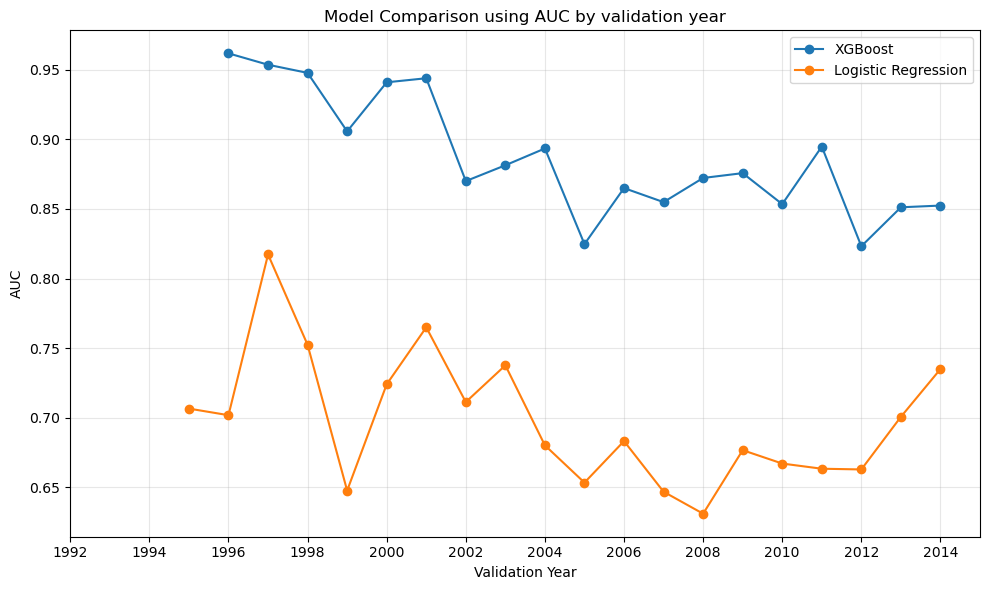

XGBoost Average AUC: 0.882875745435426
Logistic Regression Average AUC: 0.69825305


In [50]:
fold_results_xgb=pd.read_pickle("XGB.pkl")
fold_results = pd.read_csv("../Data/fold_results.csv")
plt.figure(figsize=(10,6))
plt.plot(fold_results_xgb["valid_year"][:-1], fold_results_xgb["auc_xgb"][:-1], marker="o", label="XGBoost")
plt.plot(fold_results["valid_year"], fold_results["auc_glm"], marker="o", label="Logistic Regression")
plt.xlabel("Validation Year")
plt.ylabel("AUC")
plt.xlim(1992, 2015)
plt.xticks(np.arange(1992, 2016, 2))
plt.title("Model Comparison using AUC by validation year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("XGBoost Average AUC:", fold_results_xgb["auc_xgb"].mean())
print("Logistic Regression Average AUC:", fold_results["auc_glm"].mean())

### The AUC measures the model’s ability to discriminate between positive and negative classes across all classification thresholds. An AUC of 0.5 indicates random prediction, while values closer to 1.0 indicate stronger predictive performance.
### We present the AUC by validation year comparing our benchmark logistic regression model with the XGBoost model. As shown in the figure above, the XGBoost model consistently outperforms the logistic regression benchmark across all validation years. <p>

## **Section V: Summary**


### Exploratory data analysis (EDA) of the 1.8 million wildfire records from 1992 to 2015 revealed strong spatial patterns in wildfire occurrence, with higher concentrations of notable fires appearing in several southern and western states. Aggregating the data into a county–month framework allowed us to examine wildfire activity across both geographic regions and time.
### Using this dataset, we built predictive models to estimate the probability of notable wildfire events in a future month on a county basis. Our optimized XGBoost model consistently achieved higher AUC scores than the logistic regression benchmark model (which was trained on the 100K sample dataset), indicating substantially stronger predictive performance. This improvement can likely be attributed to several factors. First, incorporating the full dataset provided more training data and improved model learning. Second, XGBoost, as a tree-based gradient boosting model, is better able to capture nonlinear relationships between predictors, which is important given the heavily skewed nature of wildfire occurrence data. Third, the addition of K-means clustering to distinguish between low and elevated risk counties likely further enhanced the XGBoost model’s predictive capability.
### These findings suggest that wildfire occurrence is influenced by complex and nonlinear relationships that are better captured by machine learning methods. Overall, this project demonstrates how large-scale wildfire records can be used to identify meaningful patterns and improve predictive modeling of wildfire risk.